In [26]:
# =============================================================================
# SECTION 1: IMPORTS FOR SENTIMENT ANALYSIS
# =============================================================================
import json
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
import torch
import random
from transformers import T5Tokenizer, T5ForConditionalGeneration
from sklearn.metrics import accuracy_score, f1_score

In [27]:
# =============================================================================
# SECTION 2: MOUNT GOOGLE DRIVE & EXTRACT DATASET
# =============================================================================
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
zip_path = '/content/drive/MyDrive/ COP528/coursework_task02_reviews.zip'
extract_to = '/content/drive/MyDrive/ COP528/reviews/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)
print('Extraction complete. Files extracted:')
for f in os.listdir(extract_to):
    if f.endswith('.jsonl'):
        size_mb = os.path.getsize(os.path.join(extract_to, f)) / (1024 ** 2)
        print(f'  {f} ({size_mb:.0f} MB)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction complete. Files extracted:
  reviews_1g_train.jsonl (920 MB)
  reviews_1g_test.jsonl (103 MB)


In [28]:
# =============================================================================
# SECTION 3: PREVIEW DATA
# =============================================================================

TRAIN_PATH = '/content/drive/MyDrive/ COP528/reviews/reviews_1g_train.jsonl'
TEST_PATH  = '/content/drive/MyDrive/ COP528/reviews/reviews_1g_test.jsonl'

for split, path in [('TRAIN', TRAIN_PATH), ('TEST', TEST_PATH)]:
    print(f"\n{'='*60}")
    print(f'[{split}] raw lines:')
    print('='*60)
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= 3:
                break
            print(f'\nLine {i+1}:\n{line.strip()}')


[TRAIN] raw lines:

Line 1:
{"review_id": "BiTunyQ73aT9WBnpR9DZGw", "stars": 5.0, "text": "I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.\n\nFor anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).\n\nThere is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class!"}

Line 2:
{"review_id": "saUsX_uimxRlCVr67Z4Jig", "stars": 3.0, "text": "

In [29]:
# =============================================================================
# SECTION 4: LOAD DATA
# =============================================================================
def load_jsonl(path, max_samples=None):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_samples and i >= max_samples:
                break
            data.append(json.loads(line))
    return pd.DataFrame(data)

print('\nLoading data...')
train_df = load_jsonl(TRAIN_PATH, max_samples=10000)
test_df  = load_jsonl(TEST_PATH,  max_samples=5000)
print(f'Train samples: {len(train_df)}')
print(f'Test samples:  {len(test_df)}')
print('\nDataFrame preview:')
print(test_df.head())



Loading data...
Train samples: 10000
Test samples:  5000

DataFrame preview:
                review_id  stars  \
0  meGaFP7yxQdjyABrYDVeoQ    1.0   
1  9IG9eB3K-RdIonPBuZ0psw    5.0   
2  OlaSUt3bA66VcCbVHhR0oA    5.0   
3  clKHv1f5cIsaJVJPdKKHZg    5.0   
4  B_O-c_YGiNRXFk3yGzYhyQ    1.0   

                                                text  
0  Skip this train wreck if you are looking for d...  
1  This is one of the busiest Chick fil A's I've ...  
2  Best place for salads! I go there every time I...  
3  WOW!  What a fantastic place!  Food A+, Servic...  
4  Called in to get service information on my 201...  


In [30]:
# =============================================================================
# SECTION 5: LABEL MAPPING
# (1-2 stars) = negative, (3 stars) = neutral, (4-5 stars) = positive
# =============================================================================
def map_sentiment(stars):
    """Convert review star ratings into sentiment classes."""

    if stars <= 2:
        return 0     # negative
    elif stars == 3:
        return 1     # neutral
    else:
        return 2     # positive

# Apply sentiment mapping to both training and test datasets
train_df['label'] = train_df['stars'].apply(map_sentiment)
test_df['label']  = test_df['stars'].apply(map_sentiment)

# Dictionary used to convert numeric labels back into readable class names
label_names = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

# Display class distribution to check dataset balance
print('\nLabel distribution (train):')
print(train_df['label'].value_counts())


Label distribution (train):
label
2    7032
0    1868
1    1100
Name: count, dtype: int64


In [31]:
# =============================================================================
# SECTION 6: LOAD PRETRAINED MODEL
# model used: nlptown/bert-base-multilingual-uncased-sentiment
# code adpated from: https://huggingface.co/blog/sentiment-analysis-python
# =============================================================================
print('\nLoading nlptown BERT model...')
classifier = pipeline(
    'text-classification',
    model='nlptown/bert-base-multilingual-uncased-sentiment',
    device=0  # GPU
)
print('Model loaded successfully.')


Loading nlptown BERT model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully.


In [32]:
# =============================================================================
# SECTION 7: MAP MODEL OUTPUT TO 3 CLASSES
# Model outputs '1 star' to '5 stars' — convert to negative/neutral/positive
# =============================================================================
def nlptown_to_label(model_output):
    """Convert predicted star rating into sentiment class."""
    stars = int(model_output['label'][0])
    if stars <= 2:
        return 0  # negative
    elif stars == 3:
        return 1  # neutral
    else:
        return 2  # positive

In [33]:
# =============================================================================
# SECTION 8: RUN PREDICTIONS IN BATCHES
# =============================================================================

# Run sentiment predictions on the test dataset in batches
print('\nRunning predictions on test set...')
test_texts  = test_df['text'].tolist()
test_labels = test_df['label'].tolist()
predictions = []
BATCH_SIZE  = 32

for i in tqdm(range(0, len(test_texts), BATCH_SIZE)):
    batch   = test_texts[i:i + BATCH_SIZE]
    results = classifier(batch, truncation=True, max_length=512)
    predictions.extend([nlptown_to_label(r) for r in results])

test_df['predicted'] = predictions
print(f'\nPredictions complete. Total reviews predicted: {len(predictions)}')



Running predictions on test set...


100%|██████████| 157/157 [01:23<00:00,  1.89it/s]


Predictions complete. Total reviews predicted: 5000


In [34]:
# =============================================================================
# SECTION 9: EVALUATE — CLASSIFICATION REPORT
# =============================================================================
print('\n--- nlptown BERT Classification Report ---')
print(classification_report(
    test_labels,
    predictions,
    target_names=['negative', 'neutral', 'positive']
))



--- nlptown BERT Classification Report ---
              precision    recall  f1-score   support

    negative       0.78      0.84      0.81       956
     neutral       0.51      0.44      0.47       570
    positive       0.93      0.93      0.93      3474

    accuracy                           0.86      5000
   macro avg       0.74      0.74      0.74      5000
weighted avg       0.85      0.86      0.85      5000



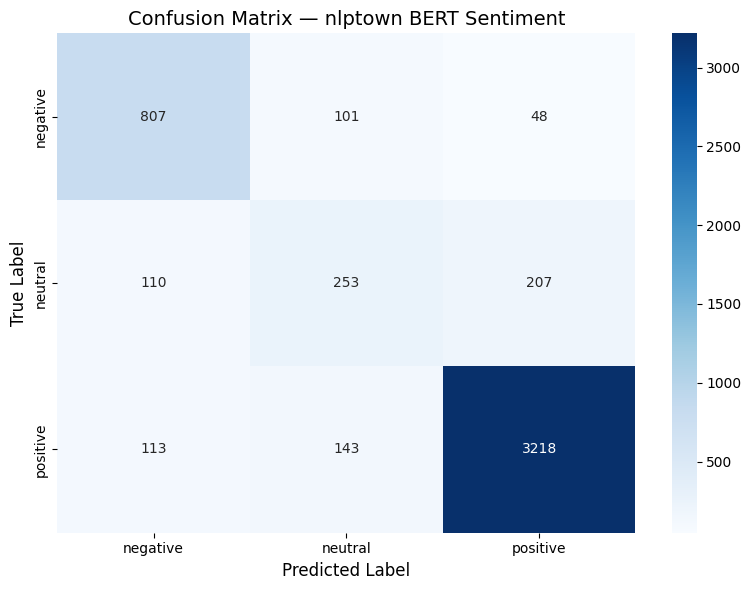

In [35]:
# =============================================================================
# SECTION 10: EVALUATE — CONFUSION MATRIX
# =============================================================================
cm = confusion_matrix(
    test_labels,
    predictions,
    labels=[0, 1, 2]
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            cmap='Blues')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix — nlptown BERT Sentiment', fontsize=14)
plt.tight_layout()
plt.show()


Loading zero-shot model...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Zero-shot model loaded.

Running zero-shot predictions...


100%|██████████| 63/63 [00:47<00:00,  1.34it/s]


--- Zero-Shot Classification Report ---
{'negative': {'precision': 0.688, 'recall': 0.8958333333333334, 'f1-score': 0.7782805429864253, 'support': 96.0}, 'neutral': {'precision': 0.3548387096774194, 'recall': 0.18333333333333332, 'f1-score': 0.24175824175824176, 'support': 60.0}, 'positive': {'precision': 0.8982558139534884, 'recall': 0.8982558139534884, 'f1-score': 0.8982558139534884, 'support': 344.0}, 'accuracy': 0.812, 'macro avg': {'precision': 0.6470315078769692, 'recall': 0.659140826873385, 'f1-score': 0.6394315328993851, 'support': 500.0}, 'weighted avg': {'precision': 0.7926766451612903, 'recall': 0.812, 'f1-score': 0.7964408532643826, 'support': 500.0}}


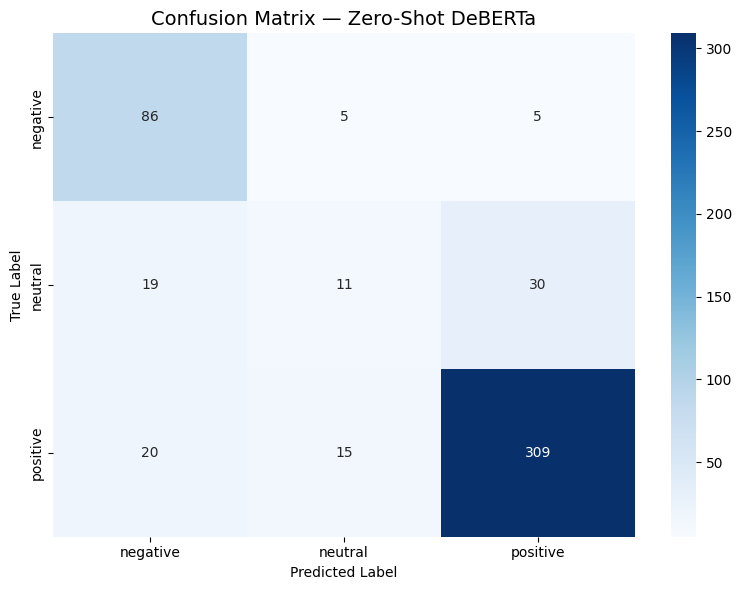

In [36]:

# =============================================================================
# SECTION 11: STRATEGY 1 — ZERO-SHOT CLASSIFICATION
# Model: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
# Adapted from:
# https://huggingface.co/tasks/zero-shot-classification
# https://towardsdatascience.com/how-to-use-zero-shot-classification-for-sentiment-analysis-abf7bd47ad25/
# =============================================================================

# pipeline() loads the model and tokeniser together as a ready-to-use
print('\nLoading zero-shot model...')
zero_shot = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli",
    device=0,
)

print('Zero-shot model loaded.')

candidate_labels = ["negative", "neutral", "positive"]

# Run on test set
sample_texts  = test_df['text'].tolist()[:500]
sample_labels = test_df['label'].tolist()[:500]

print('\nRunning zero-shot predictions...')
zero_shot_preds = []

for i in tqdm(range(0, len(sample_texts), 8)):
    batch = sample_texts[i:i+8]
    results = zero_shot(batch, candidate_labels, truncation=True, max_length=512, multi_label=False)
    for r in results:
        top_label = r['labels'][0]
        if top_label == 'negative':
            zero_shot_preds.append(0)
        elif top_label == 'neutral':
            zero_shot_preds.append(1)
        else:
            zero_shot_preds.append(2)

# Classification report for zero-shot
print('\n--- Zero-Shot Classification Report ---')
print(classification_report(
    sample_labels,
    zero_shot_preds,
    target_names=['negative', 'neutral', 'positive'],
    output_dict=True
))

# Confusion matrix for zero-shot
cm_zs = confusion_matrix(sample_labels, zero_shot_preds, labels=[0, 1, 2])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_zs, annot=True, fmt='d',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            cmap='Blues')
plt.title('Confusion Matrix — Zero-Shot DeBERTa', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


Loading FLAN-T5-Large model...


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model loaded on cuda.

Few-shot examples loaded: 9

Running few-shot predictions...


100%|██████████| 500/500 [02:45<00:00,  3.03it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Few-Shot FLAN-T5-Large Classification Report ---
{'negative': {'precision': 0.7301587301587301, 'recall': 0.9583333333333334, 'f1-score': 0.8288288288288288, 'support': 96.0}, 'neutral': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 60.0}, 'positive': {'precision': 0.893048128342246, 'recall': 0.9709302325581395, 'f1-score': 0.9303621169916435, 'support': 344.0}, 'accuracy': 0.852, 'macro avg': {'precision': 0.5410689528336587, 'recall': 0.6430878552971576, 'f1-score': 0.5863969819401574, 'support': 500.0}, 'weighted avg': {'precision': 0.7546075884899414, 'recall': 0.852, 'f1-score': 0.7992242716253859, 'support': 500.0}}


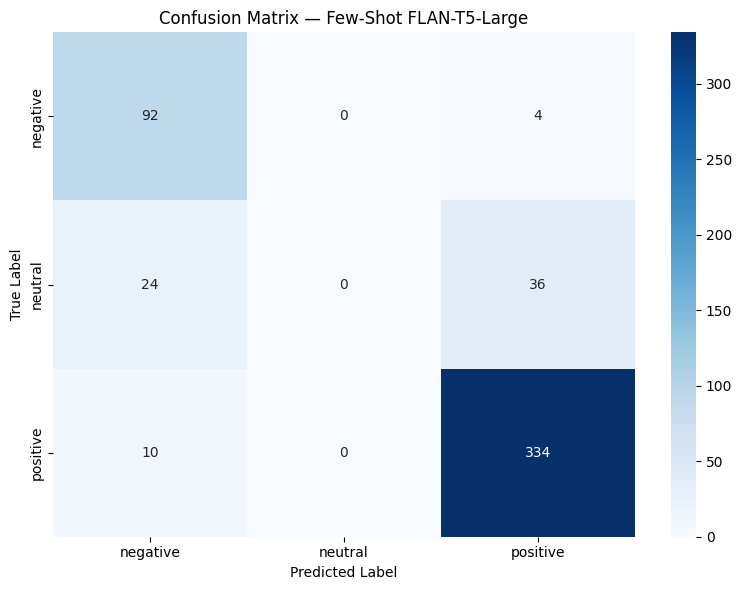

In [37]:
# =============================================================================
# SECTION 12: STRATEGY 2 — FEW-SHOT PROMPTING WITH FLAN-T5-LARGE
# Model: google/flan-t5-large
# Code adapted from: https://learn.lboro.ac.uk/pluginfile.php/2156385/mod_resource/content/5/Week08_Attn_No_Solution.pdf
# Code adapted from: https://huggingface.co/docs/transformers/tasks/prompting
# Code adapted from: https://medium.com/@tunamuna29/few-shot-zero-shot-in-nlp-45d03775e60f
# =============================================================================

# Load FLAN-T5-Large model from Hugging Face
print('\nLoading FLAN-T5-Large model...')

tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-large")
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-large")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
model.eval()

print(f'Model loaded on {device}.')

# Create few-shot training examples
random.seed(42)

label_to_name = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

few_shot_examples = []

K_SHOTS = 3

for label_id, label_name in label_to_name.items():

    # Randomly sample examples from each sentiment class
    samples = train_df[train_df['label'] == label_id].sample(
        K_SHOTS,
        random_state=42
    )

    for _, row in samples.iterrows():

        few_shot_examples.append({
            'text': row['text'],
            'label': label_name
        })

# Shuffle examples to reduce ordering bias
random.shuffle(few_shot_examples)

print(f'\nFew-shot examples loaded: {len(few_shot_examples)}')

# Build few-shot prompt
def build_prompt(review_text):

    prompt = (
        "Classify the sentiment of the following product reviews.\n"
        "Answer using only one word: negative, neutral, or positive.\n\n"
    )

    # Add labelled examples into prompt
    for ex in few_shot_examples:

        example_text = ex['text'][:150].replace('\n', ' ')

        prompt += (
            f'Review: "{example_text}"\n'
            f'Sentiment: {ex["label"]}\n\n'
        )

    # Add review to classify
    review_text = review_text[:300].replace('\n', ' ')

    prompt += (
        f'Review: "{review_text}"\n'
        f'Sentiment:'
    )

    return prompt

# Predict sentiment label
def flan_predict(text):

    prompt = build_prompt(text)

    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            num_beams=4
        )

    output = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip().lower()

    # Convert text label into numeric class
    if 'negative' in output:
        return 0

    elif 'neutral' in output:
        return 1

    elif 'positive' in output:
        return 2

    # Default fallback label
    else:
        return 1

# Run predictions
print('\nRunning few-shot predictions...')

few_shot_preds = []

for text in tqdm(sample_texts):

    pred = flan_predict(text)
    few_shot_preds.append(pred)

# Print evaluation metrics
print('\n--- Few-Shot FLAN-T5-Large Classification Report ---')

print(classification_report(
    sample_labels,
    few_shot_preds,
    target_names=['negative', 'neutral', 'positive'],
    output_dict=True
))

# Plot confusion matrix
cm_fs = confusion_matrix(
    sample_labels,
    few_shot_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_fs,
    annot=True,
    fmt='d',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive'],
    cmap='Blues'
)

plt.title('Confusion Matrix — Few-Shot FLAN-T5-Large')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

In [39]:
# =============================================================================
# SECTION 13: FINAL COMPARISON TABLE
# Compare all approaches on the same 500-sample test subset
# =============================================================================

baseline_sample_preds = test_df['predicted'].tolist()[:500]

comparison = {
    'Approach': [
        'nlptown BERT (baseline)',
        'Zero-Shot DeBERTa',
        'Few-Shot Flan-T5'
    ],
    'Accuracy': [
        round(accuracy_score(sample_labels, baseline_sample_preds), 3),
        round(accuracy_score(sample_labels, zero_shot_preds), 3),
        round(accuracy_score(sample_labels, few_shot_preds), 3)
    ],
    'Macro F1': [
        round(f1_score(sample_labels, baseline_sample_preds, average='macro'), 3),
        round(f1_score(sample_labels, zero_shot_preds, average='macro'), 3),
        round(f1_score(sample_labels, few_shot_preds, average='macro'), 3)
    ],
    'Compute Cost':        ['Medium', 'High', 'Medium'],
    'Prompt Sensitive':    ['No', 'Yes', 'Yes']
}

comparison_df = pd.DataFrame(comparison)
print('\n========== FINAL COMPARISON TABLE ==========')
print(comparison_df.to_string(index=False))
print('=============================================')


========== FINAL COMPARISON TABLE ==========
               Approach  Accuracy  Macro F1 Compute Cost Prompt Sensitive
nlptown BERT (baseline)     0.850     0.713       Medium               No
      Zero-Shot DeBERTa     0.812     0.639         High              Yes
       Few-Shot Flan-T5     0.852     0.586       Medium              Yes
